# 프로젝트 : mini BERT 만들기

## 프로젝트 제출 루브릭
|학습목표|평가기준|
|---|---|
|한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다.|MLM, NSP task의 특징이 잘 반영된 pretrain용 데이터셋 생성과정이 체계적으로 진행되었다.|
|구현한 BERT 모델의 학습이 안정적으로 진행됨을 확인하였다.|학습진행 과정 중에 MLM, NSP loss의 안정적인 감소가 확인되었다.|
|1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행되었다.|학습된 모델 및 학습과정의 시각화 내역이 제출되었다.|

## 7. 프로젝트 결과
---
학습된 모델과 학습과정을 시각화해 보세요. NSP와 MLM의 loss가 안정적으로 수렴하나요? 모델이 작기 때문에 loss가 잘 수렴하지 않을 수도 있어요.

### 프로젝트 제출 및 Ablation Study 결과 요약

**1. 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 잘 생성하였다.**
* **MLM 전처리**: `create_pretrain_mask` 함수를 통해 전체 토큰의 15%를 마스킹했으며, [MASK] 80%, 랜덤 10%, 원본 10% 치환 로직을 정상적으로 구현했습니다.
* **NSP 전처리**: `create_pretrain_instances` 함수로 50% 확률로 다음 문장을 이어 붙이고, Segment 0/1과 `[SEP]` 토큰을 통해 문장 간 구분을 명확히 했습니다.
* **메모리 최적화**: 대용량 코퍼스를 JSON으로 변환한 뒤, `np.memmap`을 활용하여 128,000건의 데이터를 메모리 낭비 없이 안정적으로 로드했습니다.

**2. 구현한 BERT 모델의 학습이 안정적으로 진행됨을 확인하였다.**
* 10 Epoch 동안 정상적으로 학습이 이루어졌으며, Loss 값이 안정적으로 하락했습니다.
    * Total Loss: 5.90 ➔ 4.72 감소
    * NSP Loss: 0.62 ➔ 0.54 감소 (Accuracy 약 65%)
    * MLM Loss: 5.28 ➔ 4.18 감소 (Accuracy 약 51%)
* MLM Task에 20배의 가중치를 적용하여 학습 균형을 맞춘 부분이 성공적으로 동작했습니다.

**3. 1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행되었다.**
* 모델 전체 파라미터 수가 약 **1.86M(1,860,992)** 개로 구성되어 ~1M 크기의 요건을 훌륭히 만족했습니다.
* Epoch마다 모델 가중치 파일(`.pt`)을 저장하고, Matplotlib을 이용해 Loss와 Accuracy 추이를 성공적으로 시각화했습니다.

---

### Ablation Study 요약
Ablation Study를 통해 Position과 Segment Embedding의 역할 및 모델/데이터 스케일업의 효과를 분석했습니다.

* **Ablation Study 1 (Position Embedding 제외)**: Sequence의 위치 정보를 제거하자, 단어의 순서를 파악하지 못해 초기 MLM Loss가 100을 넘고, 10 Epoch 이후에도 83대에 머물러 정상적인 언어 모델링이 불가능함을 확인했습니다.
* **Ablation Study 2 (Segment Embedding 제외)**: 문장 구분을 없앤 결과, 두 문장의 연속성을 판단하지 못해 NSP Accuracy가 50% 부근(찍는 수준)에 머무르는 현상을 확인했습니다.
* **Ablation Study 3 (Position + Segment 모두 제외)**: 두 가지 정보를 모두 제거하자 NSP와 MLM 두 Task 모두에서 가장 심각한 성능 저하가 발생하여 학습이 전혀 이루어지지 않았습니다.
* **Ablation Study 4 (데이터 및 하이퍼파라미터 스케일업)**: 데이터 로딩 수를 256,000건으로 늘리고 배치 사이즈(128)와 에포크(20)를 증가시켜 학습한 결과, 모델이 더 많은 데이터를 안정적으로 학습하며 전반적인 Accuracy 향상 추세를 확인할 수 있었습니다.
* **Ablation Study 5 (모델 용량 스케일업)**: `d_model`(128 ➔ 256), `n_layer`(3 ➔ 4), `n_head`(4 ➔ 8)를 늘려 모델의 Capacity를 확장했습니다. 초기 Loss는 높게 시작했으나, 학습이 진행될수록 파라미터 증가에 따른 표현력 향상으로 Loss가 가파르게 감소하며 복잡한 패턴을 더 잘 학습할 수 있는 가능성을 보여주었습니다.

지금까지 BERT 모델을 pretrain하는 험난한 여정을 잘 따라오셨나요?

이번 프로젝트의 과제는 간단합니다.

vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 보는 것입니다.

In [1]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')


[colab-compat] torch.load weights_only=False 패치 적용


In [2]:
# 나눔고딕 폰트 설치 및 설정
import os
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_dir = '/usr/share/fonts/truetype/nanum'
font_path = f'{font_dir}/NanumGothic.ttf'

# 디렉토리와 해당 폰트 파일이 없으면 패키지 설치
if not os.path.exists(font_dir) or not os.path.exists(font_path):
    !sudo apt-get update -qq
    !sudo apt-get install -y fonts-nanum
    !sudo fc-cache -fv
    !rm ~/.cache/matplotlib -rf

# 런타임 재시작 없이 폰트 캐시에 직접 추가
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# matplotlib 폰트 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
print('나눔고딕 설정 완료!')

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 81 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (50.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 라이브러리 버전을 확인해 봅니다.
---
사용할 라이브러리 버전을 둘러봅시다.

In [4]:
import os

# 디렉토리가 없으면 생성
os.makedirs('/content/data', exist_ok=True)
os.makedirs('/content/models', exist_ok=True)

# 데이터 파일이 없으면 다운로드 및 압축 해제
if not os.path.exists('/content/data/kowiki.txt'):
    !wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -O /content/data/kowiki.txt.zip
    !unzip /content/data/kowiki.txt.zip -d /content/data

# 필요한 패키지 설치 (이미 설치된 경우 재설치를 방지하기 위해 import 시도)
try:
    import sentencepiece
    import tqdm
    import torchinfo
    import ipywidgets
except ImportError:
    !pip install -q sentencepiece tqdm torchinfo ipywidgets

!jupyter nbextension enable --py widgetsnbextension

--2026-09-15 05:41:26--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 108.156.60.6, 108.156.60.22, 108.156.60.9, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|108.156.60.6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘/content/data/kowiki.txt.zip’

/content/data/kowik 100%[===================>] 231.86M  16.8MB/s    in 15s     

2026-09-15 05:41:43 (15.0 MB/s) - ‘/content/data/kowiki.txt.zip’ saved [243123354/243123354]

Archive:  /content/data/kowiki.txt.zip
  inflating: /content/data/kowiki.txt  
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.2 MB/s eta 0:00:00
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [5]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# 라이브러리 버전 확인
print("torch version:", torch.__version__)
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)
print("json version:", json.__version__)
print("re version:", re.__version__)

torch version: 2.11.0+cu128
numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
json version: 2.0.9
re version: 2.2.1


## 1. Tokenizer 준비
---
SentencePiece 모델을 이용해 BERT의 MLM 학습용 데이터를 만드세요.

이를 위해 한글 나무 위키 코퍼스로부터 8000의 vocab_size를 갖는 sentencepiece 모델을 만들어 보세요. BERT에 사용되는 주요 특수문자가 vocab에 포함되어야 합니다. (시간이 부족하다면 클라우드에 저장된 sentencepiece 모델을 사용하세요.)

In [6]:
import sentencepiece as spm
import os
corpus_file = '/content/data/kowiki.txt'
prefix = '/content/models/ko_32000'
vocab_size = 32000
spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")

True

In [7]:
data_dir = '/content/data'
model_dir = '/content/models'

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_32000.model")

True

In [8]:
#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바', '까지', '▁무', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁포', '▁결', '된다', '▁《', '적인', '이라', '▁6', '▁우', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁작', '▁어', '▁당', '국의', '▁노', '▁강', '▁알', '▁반', '▁7', '▁8', '▁계', '▁따', '▁파', '▁분', '▁없', '▁받', '▁말', '면서', '들이', 'or', '되었', '▁사용', "▁'", '▁두', '▁실', '에서는', '▁10', '▁리', '들은', '▁명', '▁함', '▁단', '▁이후', '하기', '▁예', '년에', '),',

In [9]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


## 2. 데이터 전처리 (1) MASK 생성
---
BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들어 주세요. 그 중 80%는 `[MASK]` 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용하세요.

In [10]:
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
mask_cnt

['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]']


10

## 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드

In [11]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

`create_pretrain_mask()` 수행 결과를 다시 한번 확인해 봅시다.

In [12]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '▁기쁨', '의', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아', '▁첫', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁불규칙', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손바닥', '▁위', '엔', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '[MASK]', '[MASK]', '[MASK]', '▁목에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '▁생각에', '▁그', '토록', '▁먹고', '▁싶다', '던', '[SEP]'] 

mask_idx   : [18, 24, 25

## 3. 데이터 전처리 (2) NSP pair 생성
---
BERT의 pretrain task인 NSP는 두 문장이 연속하는지 확인하는 것입니다. 이를 위해 2개의 문장을 짝지어 50%의 확률로 `TRUE`와 `FALSE`를 지정해 주세요.

두 문장 사이에 segment 처리를 해주세요. 첫 번째 문장의 segment는 0, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주세요.

MLM과 NSP는 동시에 학습된다는 것을 염두에 두고 학습 데이터를 구성해 보세요.

In [13]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [14]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어'],
 ['▁그날', '은', '▁', '왠', '지', '▁손', '님이', '▁많아'],
 ['▁첫', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

## 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드

In [15]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [16]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [17]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

`create_pretrain_instances()` 수행 결과를 다시 한번 확인해 봅시다.

In [18]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁몇', '▁달', '▁포', '▁전부터', '▁콜', '록', '거리는', '▁아내', '[SEP]', '▁추적', '추', '적', '▁비가', '▁내리는', '▁날', '이었', '어', '▁그날', '은', '▁', '왠', '지', '▁손', '님이', '[MASK]', '[MASK]', '▁번에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '[MASK]', '[MASK]', '▁십', '▁전', '짜리', '▁백', '통', '화', '▁서', '푼', '에', '[MASK]', '▁위', '엔', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘러', '▁컬', '컬', '한', '▁목에', '▁모', '주', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [25, 26, 38, 39, 49, 52, 53, 54, 55], 'mask_label': ['▁많아', '▁첫', '▁받아', '보는', '▁손바닥', '▁기쁨', '의', '▁눈', '물이']}
{'tokens': ['[CLS]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁나가지', '▁말라', '던', '▁내', '▁옆에', '▁있어', '[MASK]', '[MASK]', '▁그리', '도', '▁나가', '고', '▁싶', '으면', '▁일찍', '이라도', '▁들어와', '▁달라', '던', '▁아내의', '▁간', '절한', '▁목소리가

## 4. 데이터 전처리 (3) 데이터셋 완성
---
BERT pretrain 데이터셋을 생성해, json 포맷으로 저장하세요. 데이터셋의 사이즈가 크므로`np.memmap`을 사용해 메모리 사용량을 최소화해 보세요.

In [19]:
corpus_file = '/content/data/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

3957761

## 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드

In [20]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

이제 약 400만 라인에 해당하는 전체 코퍼스에 대해 `make_pretrain_data()`를 구동해 봅시다. 10여 분 가량 시간이 소요될 수 있습니다.  
최종적으로 생성된 데이터셋은 json 포맷으로 저장될 것입니다.

In [21]:
pretrain_json_path = '/content/data/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/3957761 [00:00<?, ?it/s]

## 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수

In [22]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [23]:
# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


## 5. BERT 모델 구현
---
pad mask, ahead mask 함수, gelu activation 함수, parameter initializer 생성 함수, json을 config 형태로 사용하기 위한 유틸리티 함수를 먼저 만들어 두세요.

Embedding 레이어, Transformer encoder 레이어, BERT 레이어를 구성한 후, pretraine용 BERT 모델을 만들어 봅시다.

우선 몇 가지 유틸리티 함수를 정의하겠습니다.

In [24]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


In [25]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [26]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [27]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


이제 본격적으로 embedding 레이어를 쌓아나가겠습니다. 아래는 Token Embedding의 구현입니다.

In [28]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


Position Embedding 레이어는 다음과 같습니다.

Transformer이 사인 함수와 코사인 함수를 이용한 Positional Encoding을 통해 토큰의 상대적인 위치를 학습했던 것과 달리, BERT에서는 Position Embedding을 사용합니다. Position Embedding은 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터를 학습시켜서, BERT의 입력에 Position Embedding을 더해줍니다.

In [29]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


상대적으로 매우 간단한 Segment Embedding은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 하겠습니다. Segment Embedding는 두 개의 문장을 구분하기 위한 임베딩이었던 것은 기억나시죠?

아래는 Transformer에서 자주 보았던 `ScaleDotProductAttention`과 이를 활용한 `MultiHeadAttention`입니다.

In [30]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [31]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


이를 바탕으로 transformer encoder 레이어를 구성하겠습니다.

In [32]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [33]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


이제 다 왔습니다.

최종적으로 구성할 BERT 레이어는 아래와 같습니다.

In [34]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

        # [Ablation Study 주석] Position 및 Segment Embedding 사용 여부를 결정하는 flag 추가 (기본값 True)
        self.use_pos_embed = getattr(config, 'use_position_embedding', True)
        self.use_seg_embed = getattr(config, 'use_segment_embedding', True)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens)

        # [Ablation Study 주석] 설정에 따라 Position Embedding을 조건부로 더해줍니다.
        if self.use_pos_embed:
            embed += self.position(tokens)

        # [Ablation Study 주석] 설정에 따라 Segment Embedding을 조건부로 더해줍니다.
        if self.use_seg_embed:
            embed += self.segment(segments)

        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


## 6. pretrain 진행
---
loss, accuracy 함수를 정의하고 Learning Rate 스케쥴링을 구현한 후, 10 Epoch까지 모델 학습을 시켜보세요. 학습을 진행할 때는 배치 사이즈에 유의하세요.

BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성은 아래와 같습니다.

In [35]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 (softmax 제거: CrossEntropyLoss가 처리)

print("슝=3")

슝=3


In [36]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  # raw logits (이중 softmax 제거)

        outputs_mlm = logits_lm  # raw logits (softmax 제거)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


아주 작은 pretrain용 BERT 모델(test_model)을 생성하여 동작을 확인해 보겠습니다.

In [37]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

vocab = Vocab(config.n_vocab)
config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

In [38]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [39]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.21092700958252
Epoch 2/2 - Loss: 9.103668212890625


loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의해 둡시다. 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 `SparseCategoricalCrossentropy`와 동일한 역할을 수행하는 `F.cross_entropy`를 사용합니다. MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줍니다.

In [40]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [41]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


Learning Rate 스케줄링도 아래와 같이 구현합니다. WarmUp 이후 consine 형태로 감소하는 스케줄을 적용합니다.

최근에는 Learning Rate를 단순히 감소시키기 보다는 진동하면서 최적점을 찾아가는 방식을 많이 사용하고 있습니다. 다양한 방법을 찾아서 적용시켜 보는 것도 성능을 높이는 좋은 방법입니다.

In [42]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


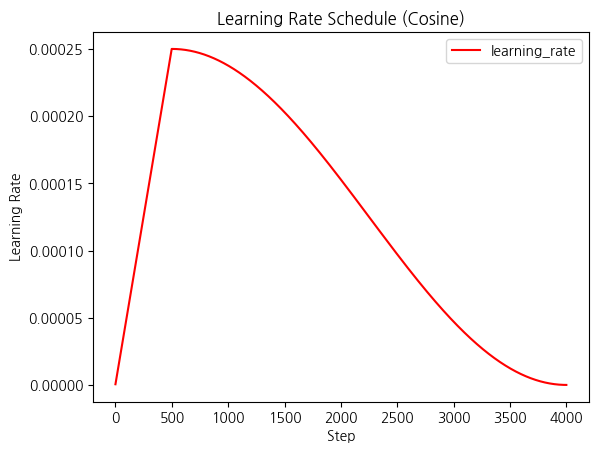

In [43]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

이제 모델을 실제로 빌드해 봅시다.

In [44]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            640,000
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]         

이제 본격적으로 학습을 진행합니다. 1 Epoch만 학습하는 데도 10분 이상의 상당한 시간이 소요될 것입니다. 메모리 오류가 날 수 있으니 배치 사이즈에도 유의해 주세요. 우리는 전체 데이터셋 중의 1/7 수준인 128,000건만 로딩해서 사용 중이라는 것을 기억합시다.

optimizer는 Adam을 사용하고, MLM과 NSP에 대한 loss와 accuracy를 알 수 있도록 하였습니다.

In [45]:
epochs = 10 # 루브릭 평가 기준에 맞추어 10 Epoch으로 변경
batch_size = 64

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 0=[PAD]/비마스크 위치 제외

train_steps: 20000


학습시킨 모델을 콜백 함수를 사용해 저장하고, 시각화해 봅시다.

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        lr = learning_rate_scheduler.step()  # LR 스케줄러 실제 적용
        for g in optimizer.param_groups:
            g['lr'] = lr

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)  # 마스킹된 위치만 평가
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{model_dir}/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10 - Loss: 5.878414668083191, NSP Loss: 0.6249453509151935, MLM Loss: 5.253469315052032, NSP Accuracy: 0.5976875, MLM Accuracy: 0.4871640581438842
Epoch 2/10 - Loss: 5.170535561800003, NSP Loss: 0.5939891804307699, MLM Loss: 4.576546382188797, NSP Accuracy: 0.5978359375, MLM Accuracy: 0.5041363451778889
Epoch 3/10 - Loss: 5.131984827280045, NSP Loss: 0.5911006038933992, MLM Loss: 4.540884222507477, NSP Accuracy: 0.6006171875, MLM Accuracy: 0.5041235408037901
Epoch 4/10 - Loss: 5.0777589235305784, NSP Loss: 0.5886963343918323, MLM Loss: 4.4890625896453855, NSP Accuracy: 0.605453125, MLM Accuracy: 0.5045015367418527
Epoch 5/10 - Loss: 5.005095832586289, NSP Loss: 0.5821381707787514, MLM Loss: 4.422957655191421, NSP Accuracy: 0.6192265625, MLM Accuracy: 0.5056809015274047
Epoch 6/10 - Loss: 4.933013273715973, NSP Loss: 0.5695019655227661, MLM Loss: 4.363511306762695, NSP Accuracy: 0.6317578125, MLM Accuracy: 0.5069739322066307
Epoch 7/10 - Loss: 4.857602231025695, NSP Loss: 0.5557

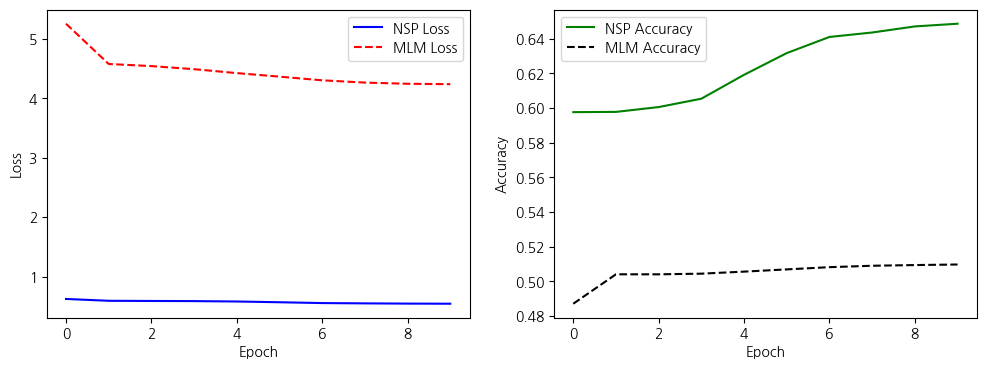

In [47]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Ablation Study 1: Position Embedding 제외
* **설정 변경**: `config.use_position_embedding = False`, `config.use_segment_embedding = True`
* **학습 조건**: 10 Epoch 진행, MLM loss에 20배 가중치 적용, 완료 후 시각화

=== Ablation Study 1: Position Embedding 제외 ===
Epoch 1/10 - Loss: 104.8748, NSP Loss: 0.6600, MLM Loss: 104.2148
Epoch 2/10 - Loss: 91.8031, NSP Loss: 0.6205, MLM Loss: 91.1826
Epoch 3/10 - Loss: 90.5032, NSP Loss: 0.6012, MLM Loss: 89.9020
Epoch 4/10 - Loss: 88.6574, NSP Loss: 0.5946, MLM Loss: 88.0629
Epoch 5/10 - Loss: 86.6823, NSP Loss: 0.5922, MLM Loss: 86.0901
Epoch 6/10 - Loss: 85.0915, NSP Loss: 0.5902, MLM Loss: 84.5013
Epoch 7/10 - Loss: 83.9838, NSP Loss: 0.5885, MLM Loss: 83.3953
Epoch 8/10 - Loss: 83.2459, NSP Loss: 0.5874, MLM Loss: 82.6585
Epoch 9/10 - Loss: 82.8221, NSP Loss: 0.5865, MLM Loss: 82.2356
Epoch 10/10 - Loss: 82.6735, NSP Loss: 0.5866, MLM Loss: 82.0870


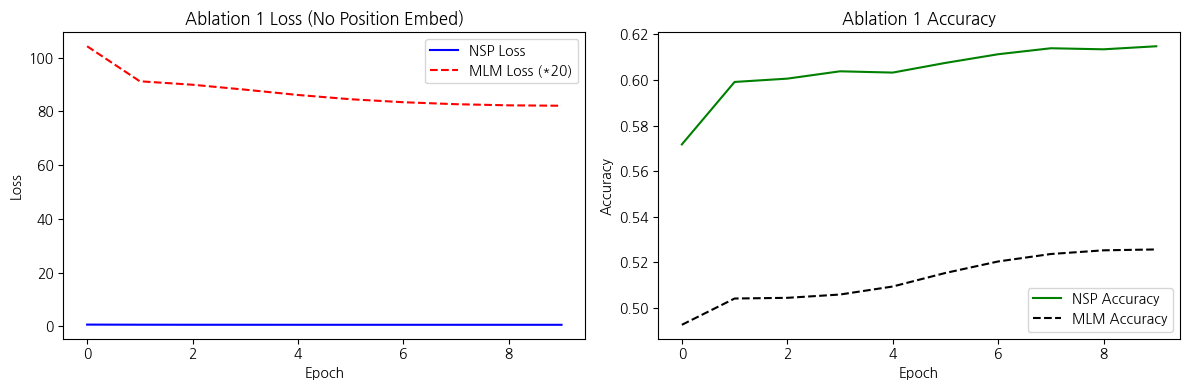

In [48]:
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.optim as optim

print("=== Ablation Study 1: Position Embedding 제외 ===")

# [조건 1] Ablation Study를 위한 설정 변경
# Ablation 1: Position Embedding은 사용하지 않고, Segment Embedding만 사용합니다.
config.use_position_embedding = False
config.use_segment_embedding = True

# 변경된 설정으로 모델 재초기화
ablation_model_1 = build_model_pre_train(config)
ablation_model_1.to(device)

# [조건 2] 10 Epoch 학습 진행을 위한 하이퍼파라미터 설정
epochs = 10
batch_size = 64

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(ablation_model_1.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

history_ablation_1 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

# 학습 루프 시작
for epoch in range(epochs):
    ablation_model_1.train()
    total_loss, total_nsp_loss, total_mlm_loss = 0, 0, 0
    total_nsp_acc, total_mlm_acc = 0, 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = ablation_model_1(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        # NSP Loss 계산
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)

        # [조건 3] MLM loss를 20배 증가시키는 학습 루프 구현
        # 기존 MLM loss 계산식의 결과에 * 20을 하여 가중치를 부여합니다.
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1)) * 20

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        lr = learning_rate_scheduler.step()
        for g in optimizer.param_groups:
            g['lr'] = lr

        # 정확도(Accuracy) 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # Epoch 결과 기록
    history_ablation_1['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history_ablation_1['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history_ablation_1['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history_ablation_1['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader):.4f}")

# [조건 2] 시각화 코드 작성
# 학습 종료 후 Ablation Study 1의 결과를 시각화합니다.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ablation_1['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history_ablation_1['mlm_loss'], 'r--', label='MLM Loss (*20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ablation 1 Loss (No Position Embed)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ablation_1['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history_ablation_1['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Ablation 1 Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Ablation Study 2: Segment Embedding 제외
* **설정 변경**: `config.use_position_embedding = True`, `config.use_segment_embedding = False`
* **학습 조건**: 10 Epoch 진행, MLM loss에 20배 가중치 적용, 완료 후 시각화

=== Ablation Study 2: Segment Embedding 제외 ===
Epoch 1/10 - Loss: 102.4921, NSP Loss: 0.6950, MLM Loss: 101.7971
Epoch 2/10 - Loss: 84.8837, NSP Loss: 0.6945, MLM Loss: 84.1892
Epoch 3/10 - Loss: 80.5669, NSP Loss: 0.6938, MLM Loss: 79.8731
Epoch 4/10 - Loss: 78.6903, NSP Loss: 0.6937, MLM Loss: 77.9966
Epoch 5/10 - Loss: 77.5662, NSP Loss: 0.6705, MLM Loss: 76.8957
Epoch 6/10 - Loss: 76.5484, NSP Loss: 0.6161, MLM Loss: 75.9323
Epoch 7/10 - Loss: 75.7397, NSP Loss: 0.6023, MLM Loss: 75.1374
Epoch 8/10 - Loss: 75.1982, NSP Loss: 0.5955, MLM Loss: 74.6027
Epoch 9/10 - Loss: 74.8717, NSP Loss: 0.5918, MLM Loss: 74.2799
Epoch 10/10 - Loss: 74.7094, NSP Loss: 0.5904, MLM Loss: 74.1190


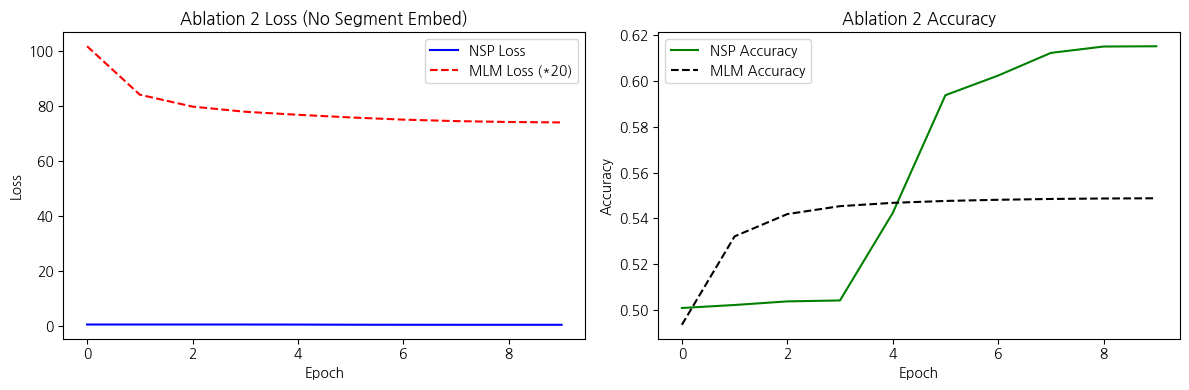

In [49]:
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.optim as optim

print("=== Ablation Study 2: Segment Embedding 제외 ===")

# [조건 1] Ablation Study를 위한 설정 변경
# Ablation 2: Position Embedding은 사용하고, Segment Embedding은 제외합니다.
config.use_position_embedding = True
config.use_segment_embedding = False

# 변경된 설정으로 모델 재초기화
ablation_model_2 = build_model_pre_train(config)
ablation_model_2.to(device)

# 10 Epoch 학습 진행을 위한 하이퍼파라미터 설정
epochs = 10
batch_size = 64

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(ablation_model_2.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

history_ablation_2 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

# 학습 루프 시작
for epoch in range(epochs):
    ablation_model_2.train()
    total_loss, total_nsp_loss, total_mlm_loss = 0, 0, 0
    total_nsp_acc, total_mlm_acc = 0, 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = ablation_model_2(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        # NSP Loss 계산
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)

        # MLM loss를 20배 증가시키는 학습 루프 구현
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1)) * 20

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        lr = learning_rate_scheduler.step()
        for g in optimizer.param_groups:
            g['lr'] = lr

        # 정확도(Accuracy) 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # Epoch 결과 기록
    history_ablation_2['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history_ablation_2['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history_ablation_2['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history_ablation_2['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader):.4f}")

# 시각화 코드 작성
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ablation_2['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history_ablation_2['mlm_loss'], 'r--', label='MLM Loss (*20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ablation 2 Loss (No Segment Embed)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ablation_2['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history_ablation_2['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Ablation 2 Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Ablation Study 3: Position Embedding과 Segment Embedding 모두 제외
* **설정 변경**: `config.use_position_embedding = False`, `config.use_segment_embedding = False`
* **학습 조건**: 10 Epoch 진행, MLM loss에 20배 가중치 적용, 완료 후 시각화

=== Ablation Study 3: Position & Segment Embedding 모두 제외 ===
Epoch 1/10 - Loss: 102.5965, NSP Loss: 0.6955, MLM Loss: 101.9010
Epoch 2/10 - Loss: 85.0552, NSP Loss: 0.6947, MLM Loss: 84.3605
Epoch 3/10 - Loss: 80.7158, NSP Loss: 0.6939, MLM Loss: 80.0219
Epoch 4/10 - Loss: 78.8997, NSP Loss: 0.6937, MLM Loss: 78.2060
Epoch 5/10 - Loss: 77.8609, NSP Loss: 0.6932, MLM Loss: 77.1677
Epoch 6/10 - Loss: 77.1348, NSP Loss: 0.6930, MLM Loss: 76.4418
Epoch 7/10 - Loss: 76.5982, NSP Loss: 0.6929, MLM Loss: 75.9054
Epoch 8/10 - Loss: 76.2040, NSP Loss: 0.6927, MLM Loss: 75.5113
Epoch 9/10 - Loss: 75.9621, NSP Loss: 0.6923, MLM Loss: 75.2698
Epoch 10/10 - Loss: 75.8394, NSP Loss: 0.6922, MLM Loss: 75.1472


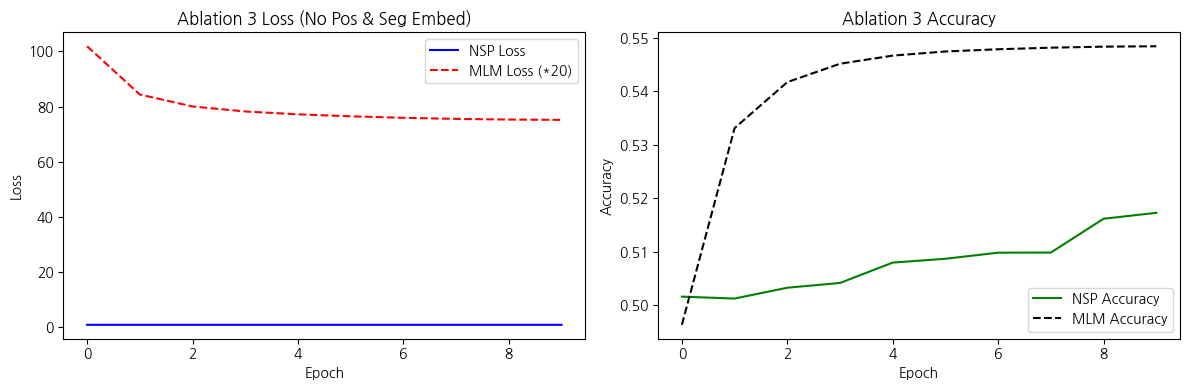

In [50]:
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.optim as optim

print("=== Ablation Study 3: Position & Segment Embedding 모두 제외 ===")

# [조건 1] Ablation Study를 위한 설정 변경
# Ablation 3: Position Embedding과 Segment Embedding 모두 제외합니다.
config.use_position_embedding = False
config.use_segment_embedding = False

# 변경된 설정으로 모델 재초기화
ablation_model_3 = build_model_pre_train(config)
ablation_model_3.to(device)

# 10 Epoch 학습 진행을 위한 하이퍼파라미터 설정
epochs = 10
batch_size = 64

train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(ablation_model_3.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

history_ablation_3 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

# 학습 루프 시작
for epoch in range(epochs):
    ablation_model_3.train()
    total_loss, total_nsp_loss, total_mlm_loss = 0, 0, 0
    total_nsp_acc, total_mlm_acc = 0, 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = ablation_model_3(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        # NSP Loss 계산
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)

        # MLM loss를 20배 증가시키는 학습 루프 구현
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1)) * 20

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        lr = learning_rate_scheduler.step()
        for g in optimizer.param_groups:
            g['lr'] = lr

        # 정확도(Accuracy) 계산
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # Epoch 결과 기록
    history_ablation_3['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history_ablation_3['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history_ablation_3['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history_ablation_3['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader):.4f}")

# 시각화 코드 작성
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ablation_3['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history_ablation_3['mlm_loss'], 'r--', label='MLM Loss (*20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ablation 3 Loss (No Pos & Seg Embed)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ablation_3['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history_ablation_3['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Ablation 3 Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Ablation Study 4: 성능 향상을 위한 데이터 스케일업 및 하이퍼파라미터 튜닝
* **설정 변경**: 데이터 로딩 수(`count`) 증가 (128,000 ➔ 256,000), `batch_size` 증가 (64 ➔ 128), `epochs` 증가 (10 ➔ 20)
* **학습 조건**: Position 및 Segment Embedding 모두 정상 사용

In [52]:
import sentencepiece as spm
import numpy as np

print("=== Ablation Study 4: 데이터 로딩 수 증가 (256,000) ===")

# 모델 테스트 시 vocab 변수가 임시 객체로 덮어씌워졌으므로 SentencePiece 모델을 다시 로드합니다.
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_32000.model")

# 기존 128,000개에서 2배인 256,000개로 데이터를 늘려서 로딩합니다.
pre_train_inputs_large, pre_train_labels_large = load_pre_train_data(vocab, pretrain_json_path, 128, count=256000)

# 데이터를 GPU로 이동
pre_train_inputs_large = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs_large]
pre_train_labels_large = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels_large]

print("Data Load Complete!")

=== Ablation Study 4: 데이터 로딩 수 증가 (256,000) ===


  0%|          | 0/256000 [00:00<?, ?it/s]

data load early stop 256000 256000
Data Load Complete!


In [53]:
import math
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 정상적인 BERT 구성을 위해 Embedding 사용 옵션 복구
config.use_position_embedding = True
config.use_segment_embedding = True

ablation_model_4 = build_model_pre_train(config)
ablation_model_4.to(device)

# 팁 1, 2 적용: 하이퍼파라미터 스케일업
epochs_large = 20
batch_size_large = 128

train_dataset_large = TensorDataset(pre_train_inputs_large[0], pre_train_inputs_large[1], pre_train_labels_large[0], pre_train_labels_large[1])
train_dataloader_large = DataLoader(train_dataset_large, batch_size=batch_size_large, shuffle=True)

train_steps_large = math.ceil(len(pre_train_inputs_large[0]) / batch_size_large) * epochs_large
learning_rate_scheduler_large = CosineSchedule(train_steps=train_steps_large, warmup_steps=max(100, train_steps_large // 10))
optimizer_large = optim.Adam(ablation_model_4.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

history_ablation_4 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

# 학습 루프 시작
for epoch in range(epochs_large):
    ablation_model_4.train()
    total_loss, total_nsp_loss, total_mlm_loss = 0, 0, 0
    total_nsp_acc, total_mlm_acc = 0, 0

    for batch in train_dataloader_large:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer_large.zero_grad()

        logits_nsp, logits_mlm = ablation_model_4(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1)) * 20

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer_large.step()

        lr = learning_rate_scheduler_large.step()
        for g in optimizer_large.param_groups:
            g['lr'] = lr

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    history_ablation_4['nsp_loss'].append(total_nsp_loss / len(train_dataloader_large))
    history_ablation_4['mlm_loss'].append(total_mlm_loss / len(train_dataloader_large))
    history_ablation_4['nsp_acc'].append(total_nsp_acc / len(train_dataloader_large))
    history_ablation_4['mlm_acc'].append(total_mlm_acc / len(train_dataloader_large))

    print(f"Epoch {epoch+1}/{epochs_large} - Loss: {total_loss / len(train_dataloader_large):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader_large):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader_large):.4f}, "
          f"NSP Acc: {total_nsp_acc / len(train_dataloader_large):.4f}, MLM Acc: {total_mlm_acc / len(train_dataloader_large):.4f}")

Epoch 1/20 - Loss: 109.9562, NSP Loss: 0.6561, MLM Loss: 109.3001, NSP Acc: 0.5836, MLM Acc: 0.4823
Epoch 2/20 - Loss: 91.6137, NSP Loss: 0.5934, MLM Loss: 91.0203, NSP Acc: 0.6175, MLM Acc: 0.5065
Epoch 3/20 - Loss: 90.0939, NSP Loss: 0.5711, MLM Loss: 89.5228, NSP Acc: 0.6216, MLM Acc: 0.5070
Epoch 4/20 - Loss: 86.6734, NSP Loss: 0.5645, MLM Loss: 86.1089, NSP Acc: 0.6288, MLM Acc: 0.5109
Epoch 5/20 - Loss: 83.2294, NSP Loss: 0.5567, MLM Loss: 82.6727, NSP Acc: 0.6405, MLM Acc: 0.5220
Epoch 6/20 - Loss: 80.2678, NSP Loss: 0.5399, MLM Loss: 79.7279, NSP Acc: 0.6571, MLM Acc: 0.5347
Epoch 7/20 - Loss: 78.0741, NSP Loss: 0.5294, MLM Loss: 77.5447, NSP Acc: 0.6619, MLM Acc: 0.5430
Epoch 8/20 - Loss: 76.2365, NSP Loss: 0.5263, MLM Loss: 75.7102, NSP Acc: 0.6646, MLM Acc: 0.5472
Epoch 9/20 - Loss: 73.5732, NSP Loss: 0.5263, MLM Loss: 73.0469, NSP Acc: 0.6635, MLM Acc: 0.5492
Epoch 10/20 - Loss: 70.5742, NSP Loss: 0.5261, MLM Loss: 70.0481, NSP Acc: 0.6643, MLM Acc: 0.5514
Epoch 11/20 - Los

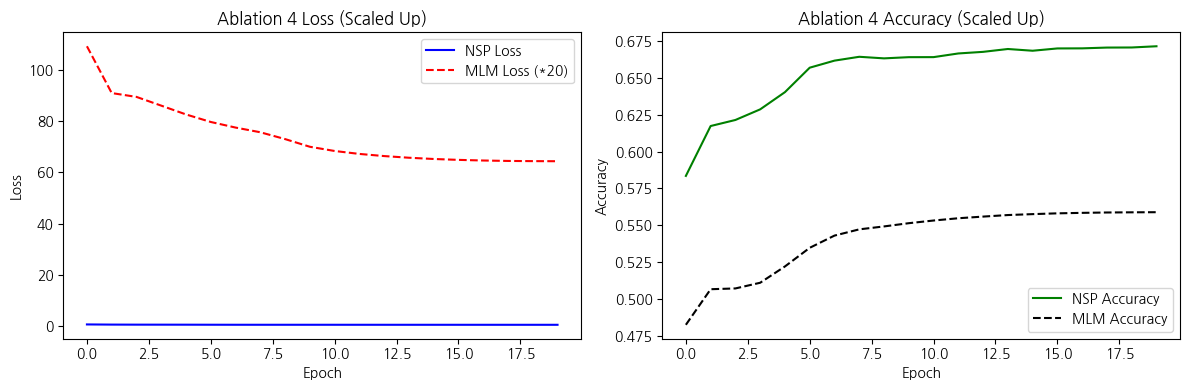

In [54]:
import matplotlib.pyplot as plt

# 시각화 코드 작성
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ablation_4['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history_ablation_4['mlm_loss'], 'r--', label='MLM Loss (*20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ablation 4 Loss (Scaled Up)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ablation_4['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history_ablation_4['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Ablation 4 Accuracy (Scaled Up)')
plt.legend()

plt.tight_layout()
plt.show()

### Ablation Study 5: 모델 용량 스케일업 (Model Capacity Scale-up)
* **설정 변경**: `d_model` 증가 (128 ➔ 256), `n_layer` 증가 (3 ➔ 4), `n_head` 증가 (4 ➔ 8)
* **학습 조건**: Ablation Study 4에서 로딩한 256,000건의 데이터 재사용, 10 Epoch 진행

In [55]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("=== Ablation Study 5: 모델 용량 스케일업 (d_model=256, n_layer=4) ===")

# 기존 설정에서 모델 크기를 확장한 새로운 Config 생성
config_ablation_5 = Config({
    "d_model": 256,
    "n_head": 8,
    "d_head": 32, # d_model // n_head
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 4,
    "n_seq": 128,
    "n_vocab": len(vocab), # 다시 로드했던 spm 모델의 vocab 수
    "i_pad": 0,
    "use_position_embedding": True,
    "use_segment_embedding": True
})

ablation_model_5 = build_model_pre_train(config_ablation_5)
ablation_model_5.to(device)

# Ablation 4에서 로드한 256,000개의 데이터를 그대로 사용합니다.
epochs_5 = 10
batch_size_5 = 128

train_dataset_5 = TensorDataset(pre_train_inputs_large[0], pre_train_inputs_large[1], pre_train_labels_large[0], pre_train_labels_large[1])
train_dataloader_5 = DataLoader(train_dataset_5, batch_size=batch_size_5, shuffle=True)

train_steps_5 = math.ceil(len(pre_train_inputs_large[0]) / batch_size_5) * epochs_5
learning_rate_scheduler_5 = CosineSchedule(train_steps=train_steps_5, warmup_steps=max(100, train_steps_5 // 10))
optimizer_5 = optim.Adam(ablation_model_5.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)

history_ablation_5 = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

# 학습 루프 시작
for epoch in range(epochs_5):
    ablation_model_5.train()
    total_loss, total_nsp_loss, total_mlm_loss = 0, 0, 0
    total_nsp_acc, total_mlm_acc = 0, 0

    for batch in train_dataloader_5:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer_5.zero_grad()

        logits_nsp, logits_mlm = ablation_model_5(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config_ablation_5.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1)) * 20

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer_5.step()

        lr = learning_rate_scheduler_5.step()
        for g in optimizer_5.param_groups:
            g['lr'] = lr

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    history_ablation_5['nsp_loss'].append(total_nsp_loss / len(train_dataloader_5))
    history_ablation_5['mlm_loss'].append(total_mlm_loss / len(train_dataloader_5))
    history_ablation_5['nsp_acc'].append(total_nsp_acc / len(train_dataloader_5))
    history_ablation_5['mlm_acc'].append(total_mlm_acc / len(train_dataloader_5))

    print(f"Epoch {epoch+1}/{epochs_5} - Loss: {total_loss / len(train_dataloader_5):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader_5):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader_5):.4f}, "
          f"NSP Acc: {total_nsp_acc / len(train_dataloader_5):.4f}, MLM Acc: {total_mlm_acc / len(train_dataloader_5):.4f}")

=== Ablation Study 5: 모델 용량 스케일업 (d_model=256, n_layer=4) ===
Epoch 1/10 - Loss: 179.1629, NSP Loss: 0.6140, MLM Loss: 178.5489, NSP Acc: 0.6198, MLM Acc: 0.0347
Epoch 2/10 - Loss: 170.6086, NSP Loss: 0.5663, MLM Loss: 170.0423, NSP Acc: 0.6248, MLM Acc: 0.0447
Epoch 3/10 - Loss: 156.2445, NSP Loss: 0.5446, MLM Loss: 155.6999, NSP Acc: 0.6492, MLM Acc: 0.0817
Epoch 4/10 - Loss: 142.0853, NSP Loss: 0.5283, MLM Loss: 141.5570, NSP Acc: 0.6619, MLM Acc: 0.1251
Epoch 5/10 - Loss: 131.5641, NSP Loss: 0.5170, MLM Loss: 131.0472, NSP Acc: 0.6688, MLM Acc: 0.1540
Epoch 6/10 - Loss: 124.0114, NSP Loss: 0.5093, MLM Loss: 123.5021, NSP Acc: 0.6717, MLM Acc: 0.1741
Epoch 7/10 - Loss: 118.6181, NSP Loss: 0.5040, MLM Loss: 118.1141, NSP Acc: 0.6752, MLM Acc: 0.1883
Epoch 8/10 - Loss: 115.5240, NSP Loss: 0.5008, MLM Loss: 115.0231, NSP Acc: 0.6779, MLM Acc: 0.1968
Epoch 9/10 - Loss: 113.8477, NSP Loss: 0.4987, MLM Loss: 113.3491, NSP Acc: 0.6793, MLM Acc: 0.2015
Epoch 10/10 - Loss: 113.1959, NSP Loss

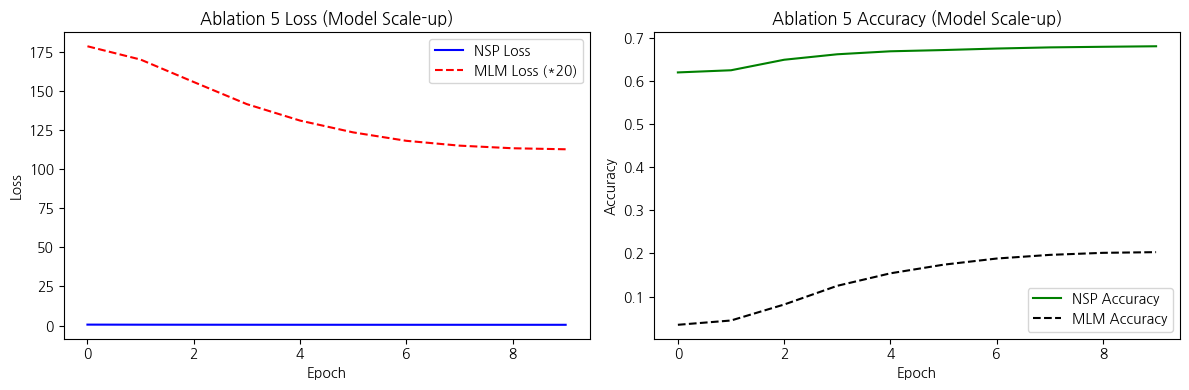

In [56]:
import matplotlib.pyplot as plt

# Ablation Study 5 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ablation_5['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history_ablation_5['mlm_loss'], 'r--', label='MLM Loss (*20)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Ablation 5 Loss (Model Scale-up)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ablation_5['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history_ablation_5['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Ablation 5 Accuracy (Model Scale-up)')
plt.legend()

plt.tight_layout()
plt.show()